# Break Through Tech AI: Nestlé 1A Group
## Stage 2: Data Preprocessing

We have merged the User Reviews file and Item Metadata file into a Pandas dataframe, to be preprocessed for usage in trend analysis, sentiment analysis, and time-series analysis.

#### Step 0. Update, Install, and Import Python Libraries

In [1]:
#%pip install --upgrade pip
#%pip install -q datasets huggingface_hub pyarrow pandas
#%pip install matplotlib
#%pip install seaborn
#%pip install scikit-learn
#%pip install seaborn

In [14]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from tqdm import tqdm
import gc
import glob
import json
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import sklearn

In [31]:
from scipy.stats.mstats import winsorize
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, log_loss, confusion_matrix, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV

#### Step 1. Import DataFrame

In [3]:
file_pattern = 'top_data/**/*.parquet' 
parquet_files = glob.glob(file_pattern, recursive=True)
 
# Reads each parquet file and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(fp) for fp in parquet_files], ignore_index=True)

In [4]:
df.shape

(1061601, 18)

In [5]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_meta,main_category,average_rating,rating_number,price,details,year_quarter,Flavor
0,2.0,The coconut overpowers the coffee. Not a favo...,No coffee taste,[],B003G52BN0,B007OYG9AA,AEL5UWA7CAG45FN7GZEG7SE4XHUA,2018-07-21 16:57:57.788,0,True,Green Mountain Coffee Roasters French Vanilla ...,Grocery,4.7,26679,NaN,"{'Age Range (Description)': None, 'Age Range D...",2018Q3,French Vanilla
1,5.0,Yum,Big box of Twix. Yum. Perfect for my child who...,[],B0029JE7RC,B071KL86P1,AG6G5IZRETKHWANDEC3N43ANN3YQ,2023-01-17 00:26:20.400,0,True,Twix TWIX Singles Size White Chocolate Caramel...,Grocery,4.4,1042,NaN,"{'Age Range (Description)': None, 'Age Range D...",2023Q1,Chocolate
2,1.0,Repeatedly sent the wrong number of cookies,Love these cookies. Don’t love the seller.<br ...,[],B0964H46TF,B09JGWP155,AEN6FHORVITRRZTUE4IFFPUDQUNQ,2022-07-21 04:54:52.430,2,True,Quest Nutrition Chocolate Cake Frosted Cookies...,Health & Personal Care,4.6,3693,26.64,"{'Age Range (Description)': None, 'Age Range D...",2022Q3,Chocolate
3,5.0,Potent and flavorful!,My girlfriend's Christmas tradition is to make...,[],B00F3OAKJ4,B07MCCC7YM,AEJQJMK5GZK4NAQ3L3XV76CJEUHA,2018-01-23 02:16:19.563,11,True,"LorAnn Cinnamon Oil SS Flavor, 1 dram bottle (...",Amazon Home,4.7,964,3.45,"{'Age Range (Description)': None, 'Age Range D...",2018Q1,Cinnamon
4,5.0,Five Stars,Grandkids loved it.,[],B07658D4CK,B07658D4CK,AEXLWUJLIVNRLVF6HRMKQLJEUXEQ,2018-01-17 13:41:15.576,0,True,Halloween Skull White Bucket with Assorted Cho...,Grocery,4.1,27,NaN,"{'Age Range (Description)': None, 'Age Range D...",2018Q1,Dark Chocolate


#### Step 2. Define the Label

In [48]:
def map_label(num):
    if num < 3:
        return 0
    elif num == 3:
        return 1
    else:
        return 2

In [42]:
X = df[["text"]].copy()
X.shape

(1061601, 1)

In [49]:
df["label"] = df["rating"].apply(map_label)
y = df["label"].copy()

#### Step 3. Split the data into training and test sets

In [52]:
# Train the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

#### Step 4. Address Class Imbalance

In [53]:
y_train.value_counts()

label
2    634810
0    161145
1     53325
Name: count, dtype: int64

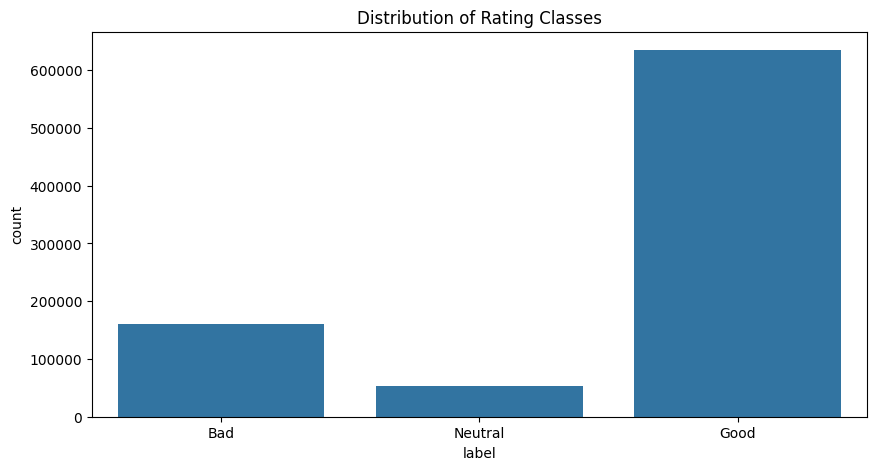

In [55]:
# Visualize the class distribution for ratings
plt.figure(figsize = (10, 5))
sns.countplot(x = y_train)
plt.title('Distribution of Rating Classes')
plt.xticks([0, 1, 2], ['Bad', 'Neutral', 'Good'])
plt.show()

I plan to do stratified sampling and batch rebalancing to address the class imbalance between bad, neutral and good ratings.

#### Step 5. Extract flavor components from examples

In [56]:
df["details"].str.get("Flavor").value_counts()

details
Chocolate                      87946
Caramel                        33947
Vanilla                        31154
Fruit                          28362
Milk Chocolate                 27756
                               ...  
Himalayan                       3577
Cookies                         3547
Whole Bean                      3528
Guava                           3497
Pure Lemon + Baking Vanilla     3454
Name: count, Length: 100, dtype: int64